# Public Sentiment and Discussion Patterns Surrounding Formula 1 Safety on X

**Course:** COSC2671 Social Media and Network Analytics  
**Assignment:** Assignment 2  
**Topic:** Formula 1 safety discussions on Youtube 

This notebook investigates how users on Youtube discuss Formula 1 safety issues. The analysis combines text preprocessing, exploratory data analysis, sentiment analysis, topic modelling, and network analysis to understand the main themes and patterns in public discussion.

## 1. Introduction (draft 1)

### Discussion
 This study analyses public discussion on Youtube around Formula 1 safety to identify dominant themes, sentiment patterns, and network structures within safety-related conversations.

Possible research questions:

1. What are the most common topics in F1 safety discussions on Youtube?
2. Is public sentiment mostly positive, negative, or neutral?
3. Which hashtags, keywords, or user mentions are most central in the discussion network?
4. How do sentiment and topic patterns connect with network communities?

Social media platforms have become a primary source of discussion, opinion formation, and exchange of information. Users not only express their views through text but also interact with one another, forming complex networks of influence and engagement. 
As a result, analysing online content requires more than just traditional text mining techniques — it demands an integrated approach that considers both what people say and how they are connected.

This study explores discussions surrounding *how does social media discussion influence perceptions of safety in Formula 1 after major accidents* by combining Natural Language Processing (NLP) and network analysis. 
The goal is to move beyond surface-level insights and uncover deeper patterns in sentiment, and interaction structures, by leveraging methods such as sentiment analysis, topic modelling, and transformer-based language models. The textual content of user-generated data can be systematically examined. At the same time, constructing and analysing interaction networks enables the identification of influential entities, community structures, and patterns of information flow.

## 2. Setup and Imports

Install the required libraries first if needed:

In [1]:
!pip install google-api-python-client pandas numpy matplotlib seaborn nltk textblob langdetect scikit-learn networkx python-louvain wordcloud transformers torch sentence-transformers deep_translator

In [2]:
# Core data tools
import os
import re
import json
import time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# YouTube API
from googleapiclient.discovery import build
from googleapiclient.errors import HttpError

# Language detection
from langdetect import detect, LangDetectException

# NLP
import nltk
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

# Feature extraction and topic modelling
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

# Network analysis
import networkx as nx

# Optional community detection
try:
    import community as community_louvain
    HAS_LOUVAIN = True
except ImportError:
    HAS_LOUVAIN = False

# Optional BERT / sentence embeddings
try:
    from sentence_transformers import SentenceTransformer
    HAS_SENTENCE_TRANSFORMERS = True
except ImportError:
    HAS_SENTENCE_TRANSFORMERS = False

# Download NLTK resources if needed
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('wordnet')
nltk.download('omw-1.4')

pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\davin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\davin\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\davin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\davin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 3. YouTube API

In [3]:
# ── YouTubeProcessing.py ───────────────────────────────────
# Provides the YouTubeProcessing class with a .process() method.
# Centralises tokenisation + stopword filtering (no stemming).
from YouTubeProcessing import YouTubeProcessing

# ── youtubeTextProcessing.py ───────────────────────────────
# Provides processText() which adds Porter stemming on top.
# This function is what youtubeTextProcessing.py uses in its main loop.


print('Helper modules imported.')
print('  YouTubeProcessing.process() — tokenise + filter (no stemming)')
print('  processText()               — tokenise + stem + stopword removal')

Helper modules imported.
  YouTubeProcessing.process() — tokenise + filter (no stemming)
  processText()               — tokenise + stem + stopword removal


## 5. Collect Video Metadata

This section queries YouTube to discover relevant Formula 1 safety videos and saves detailed video metadata. Video-level information supports exploratory analysis and helps connect comment sentiment, topics, and engagement patterns back to the most important source videos.

In [4]:
from fetchYoutubeAPI import (
    SEARCH_QUERIES,
    search_videos_for_query,
    get_video_details
)

from youtubeClient import youtubeClient

client = youtubeClient()

MAX_TOTAL_VIDEOS = 60
VIDEOS_PER_QUERY = 10

all_items = []

for query in SEARCH_QUERIES:

    # Stop once enough videos collected
    if len(all_items) >= MAX_TOTAL_VIDEOS:
        break

    try:
        print(f"Searching: {query}")

        items = search_videos_for_query(
            client=client,
            query=query,
            max_videos=VIDEOS_PER_QUERY,
            published_after="2020-01-01T00:00:00Z"
        )

        all_items.extend(items)

        time.sleep(0.2)

    except HttpError as e:
        print(f"API error for query '{query}': {e}")

# Convert raw search results into video IDs
video_ids = [
    item["id"]["videoId"]
    for item in all_items
    if "id" in item and "videoId" in item["id"]
]

# Remove duplicates
video_ids = list(dict.fromkeys(video_ids))

# Final cap on total videos
video_ids = video_ids[:MAX_TOTAL_VIDEOS]

# Fetch detailed metadata/statistics
videos = get_video_details(client, video_ids)

video_df = pd.DataFrame(videos)

print(video_df.shape)
video_df.head()

Searching: Formula 1 crash analysis
Searching: F1 major accidents analysis
Searching: Formula 1 safety discussion
Searching: F1 halo safety analysis
Searching: Formula 1 dangerous crashes
Searching: Jules Bianchi crash analysis
(46, 10)


,title,videoId,channelTitle,publishedAt,viewCount,likeCount,commentCount,durationSecs,category,comments
0,Doctor Diagnoses Unreal Racing Crashes,_Ji8Rud1bRE,Doctor Mike,2022-11-20T15:00:18Z,12775716,260825,10604,949,safety_discussion,[]
1,How Grosjean's Accident Happened | 2020 Bahrain Grand Prix | Jolyon Palmer Analysis,EyTeDaiUL6s,FORMULA 1,2020-12-01T19:30:01Z,2864877,56258,2311,692,safety_discussion,[]
2,The Race Start Chaos & Major Incidents from The Miami Grand Prix | Jolyon Palmer's F1 TV Analysis,4703BVI4Giw,FORMULA 1,2026-05-05T14:30:35Z,111953,2896,324,849,safety_discussion,[]
3,The Horrifying Tragedy F1 Wants You To Forget..,6D4j1P0RcL4,DailyFuelUp,2025-04-11T12:00:15Z,769493,7247,567,696,safety_discussion,[]
4,20 Times Pit Stops Went Wrong!,1tAwfD0PTsY,FORMULA 1,2024-07-12T16:00:02Z,7482649,57302,1231,710,safety_discussion,[]


### Video Collection and Metadata Retrieval

This section collects YouTube videos related to the selected Formula 1 safety topics using the YouTube Data API. The process begins by iterating through a predefined list of search queries (SEARCH_QUERIES), where each query targets a specific aspect of F1 safety discussions, incidents, regulations, or public reactions.

To ensure a balanced dataset and avoid excessive API usage, the notebook limits the number of videos retrieved per query (VIDEOS_PER_QUERY) and applies an overall cap (MAX_TOTAL_VIDEOS). Videos are filtered to only include content published after January 1st, 2020, allowing the analysis to focus on modern discussions and recent developments in Formula 1 safety.

The retrieved search results are then processed to extract unique video IDs while removing duplicates that may appear across multiple queries. Using these video IDs, additional metadata is collected through the get_video_details() function, including attributes such as:

Video title
Channel name
Publish date
View count
Like count
Comment count

Finally, the data is converted into a Pandas DataFrame (video_df) to prepare it for downstream analysis tasks such as exploratory data analysis (EDA), sentiment analysis, topic modelling, and network analysis.

This approach ensures that the dataset is both relevant and manageable while maintaining diversity across different safety-related discussions within the Formula 1 community.

In [5]:
# Save raw video metadata
os.makedirs("data", exist_ok=True)
video_df.to_csv("data/f1_safety_videos.csv", index=False)
video_df.to_json("data/f1_safety_videos.json", orient="records", indent=2)
print("Saved video metadata.")

Saved video metadata.


## 6. Collect YouTube Comments

The function below collects top-level comments from each video. Replies can be added later, but top-level comments are usually enough for sentiment, topic modelling, and co-occurrence networks.

The notebook saves raw comments so the API does not need to be called repeatedly.

In [6]:
from fetchYoutubeAPI import get_comments_for_video
from youtubeClient import youtubeClient
import pandas as pd

client = youtubeClient()

MAX_COMMENTS_OVERALL = 20000
MAX_COMMENTS_PER_VIDEO = 500

all_comments = []

for idx, row in video_df.iterrows():

    remaining_comments = MAX_COMMENTS_OVERALL - len(all_comments)

    if remaining_comments <= 0:
        print("Reached overall comment limit.")
        break

    comments_to_fetch = min(MAX_COMMENTS_PER_VIDEO, remaining_comments)

    print(
        f"Collecting comments for "
        f"{idx+1}/{len(video_df)}: "
        f"{row['title'][:80]}"
    )

    comments = get_comments_for_video(
        client=client,
        video_id=row["videoId"],
        max_comments=comments_to_fetch
    )

    for c in comments:
        c["videoId"] = row["videoId"]
        c["videoTitle"] = row["title"]

    all_comments.extend(comments)

    print(f"Total comments collected so far: {len(all_comments)}")

comments_df = pd.DataFrame(all_comments)

print(comments_df.shape)
comments_df.head()

Total comments collected so far: 500
Total comments collected so far: 1000
Total comments collected so far: 1120
Total comments collected so far: 1399
Total comments collected so far: 1899
Total comments collected so far: 2058
Total comments collected so far: 2558
Total comments collected so far: 2651
Total comments collected so far: 3151
Total comments collected so far: 3437
Total comments collected so far: 3811
Total comments collected so far: 4157
Total comments collected so far: 4412
Total comments collected so far: 4912
Total comments collected so far: 5412
Total comments collected so far: 5912
Total comments collected so far: 6163
Total comments collected so far: 6663
Total comments collected so far: 6764
Total comments collected so far: 6995
Total comments collected so far: 7495
Total comments collected so far: 7501
Total comments collected so far: 7548
Total comments collected so far: 7655
Total comments collected so far: 8155
Total comments collected so far: 8203
Total comment

,author,text,originalText,originalLang,publishedAt,likeCount,videoId,videoTitle
0,@krzysztofszczygie6735,"Gorsjean not only survived 160mph crash, but he stayed in the flames for 27seconds. That's just amazing how much saf...","Gorsjean not only survived 160mph crash, but he stayed in the flames for 27seconds. That's just amazing how much saf...",en,2022-11-23T08:09:43Z,48798,_Ji8Rud1bRE,Doctor Diagnoses Unreal Racing Crashes
1,@TG_39438,Here’s kind of a sad fact: Romain Grosjean was actually very close to just staying down in the car because he was at...,Here’s kind of a sad fact: Romain Grosjean was actually very close to just staying down in the car because he was at...,en,2023-02-04T17:57:42Z,14107,_Ji8Rud1bRE,Doctor Diagnoses Unreal Racing Crashes
2,@catz8449,One of the scariest things about Grosjean’s crash is that the height of his body and the design of the barrier means...,One of the scariest things about Grosjean’s crash is that the height of his body and the design of the barrier means...,en,2022-12-11T16:35:04Z,11977,_Ji8Rud1bRE,Doctor Diagnoses Unreal Racing Crashes
3,@Shuckles153,that man who walked out of the fire said that the only reason he could walk out was because he thought about his chi...,that man who walked out of the fire said that the only reason he could walk out was because he thought about his chi...,en,2025-05-28T16:06:26Z,586,_Ji8Rud1bRE,Doctor Diagnoses Unreal Racing Crashes
4,@Huckle15,"I was watching Bahrain 2020 live, I really thought I had just witnessed somebody die instantly. The fact that Grosje...","I was watching Bahrain 2020 live, I really thought I had just witnessed somebody die instantly. The fact that Grosje...",en,2022-11-20T15:12:11Z,6988,_Ji8Rud1bRE,Doctor Diagnoses Unreal Racing Crashes


### Comment Collection from YouTube Videos

This section retrieves user comments from the previously collected YouTube videos in order to analyse public discussion surrounding Formula 1 safety. Comments provide valuable insight into audience opinions, emotional reactions, debates, and recurring themes related to crashes, regulations, driver safety, and FIA decisions.

Using the YouTube Data API, comments are collected for each video stored in `video_df`. To maintain a manageable and balanced dataset, the notebook applies two limits:

- `MAX_COMMENTS_PER_VIDEO` restricts the number of comments retrieved from a single video.
- `MAX_COMMENTS_OVERALL` sets a global cap on the total number of comments collected across the entire dataset.

For each video, the `get_comments_for_video()` function retrieves comment data including the comment text and associated metadata. Additional contextual information is then attached to every comment, including:

- `videoId` — the unique identifier of the source video  
- `videoTitle` — the title of the video where the comment originated  

This linkage is important because it allows comments to later be analysed in relation to specific videos, incidents, or discussion topics.

The iterative collection process also ensures that API usage remains controlled while progressively building a large-scale dataset suitable for natural language processing (NLP) and network analysis tasks. Once all comments are gathered, the results are converted into a Pandas DataFrame (`comments_df`) for further preprocessing and analysis.

The resulting dataset forms the core textual corpus used throughout the project for:
- Sentiment analysis (VADER and BERT)
- Topic modelling (LDA)
- TF-IDF and bigram analysis
- Community and interaction analysis
- NLP and network integration

By collecting comments directly from YouTube discussions, the dataset captures authentic public reactions and conversations surrounding safety in modern Formula 1 racing.

In [7]:
# Save raw comments
comments_df.to_csv("data/f1_safety_comments_raw.csv", index=False)
comments_df.to_json("data/f1_safety_comments_raw.json", orient="records", indent=2)
print("Saved raw comments.")

Saved raw comments.


## 7. Load Saved Data

After collecting data once, use this section in later runs to avoid spending API quota.

In [8]:
# Uncomment these lines if you already collected and saved the data
# video_df = pd.read_csv("data/f1_safety_videos.csv")
# comments_df = pd.read_csv("data/f1_safety_comments_raw.csv")

print(video_df.shape)
print(comments_df.shape)

(46, 10)
(12358, 8)


## 8. Data Cleaning

### Data Cleaning and Further Pre-processing

Raw social media data often contains noise and inconsistencies that can negatively affect downstream NLP and network analysis tasks. Therefore, an additional cleaning and preprocessing stage is performed to improve the overall quality, consistency, and reliability of the dataset.

A custom cleaning function, `clean_basic_text()`, is applied to each comment to remove unnecessary textual elements commonly found in online discussions, including:

- URLs and website links  
- User mentions (`@username`)  
- Hashtags  
- Excess whitespace and formatting inconsistencies  

These elements are removed because they typically provide limited semantic value for sentiment analysis or topic modelling and may introduce noise into the feature extraction process.

After the initial text cleaning stage, several additional preprocessing steps are performed:

- Comments are converted to string format to ensure consistency across the dataset.
- Empty comments are removed to avoid invalid or meaningless entries.
- Duplicate comments are removed using the cleaned text field (`text_clean_basic`) to reduce redundancy and prevent repeated messages from biasing the analysis.

The notebook also converts publication timestamps into proper datetime objects for both videos and comments. This enables potential temporal analysis later in the project, such as examining how public sentiment or discussion topics evolve over time.

The cleaned dataset (`comments_clean`) provides a more structured and reliable textual corpus for the later stages of the analysis pipeline, including:
- TF-IDF feature extraction
- Bigram analysis
- Sentiment analysis
- Topic modelling
- BERT-based semantic analysis
- Network construction

This preprocessing stage is important because the quality of text preparation directly influences the performance and interpretability of NLP models and analytical results.

In [9]:
## Data cleaning and further pre-processing
def clean_basic_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)      # remove URLs
    text = re.sub(r"@[A-Za-z0-9_]+", " ", text)          # remove mentions
    text = re.sub(r"#[A-Za-z0-9_]+", " ", text)          # remove hashtags symbol and term
    text = re.sub(r"\s+", " ", text).strip()
    return text

comments_clean = comments_df.copy()
comments_clean["text"] = comments_clean["text"].astype(str)
comments_clean["text_clean_basic"] = comments_clean["text"].apply(clean_basic_text)

# Remove empty and duplicate comments
comments_clean = comments_clean[comments_clean["text_clean_basic"].str.len() > 0]
comments_clean = comments_clean.drop_duplicates(subset="text_clean_basic")

# Convert dates to datetime (for video_df and comments_df if applicable)
video_df["publishedAt"] = pd.to_datetime(video_df["publishedAt"])
if "publishedAt" in comments_clean.columns:
    comments_clean["publishedAt"] = pd.to_datetime(comments_clean["publishedAt"])

print(comments_clean.shape)
comments_clean.head()

(12321, 9)


,author,text,originalText,originalLang,publishedAt,likeCount,videoId,videoTitle,text_clean_basic
0,@krzysztofszczygie6735,"Gorsjean not only survived 160mph crash, but he stayed in the flames for 27seconds. That's just amazing how much saf...","Gorsjean not only survived 160mph crash, but he stayed in the flames for 27seconds. That's just amazing how much saf...",en,2022-11-23 08:09:43+00:00,48798,_Ji8Rud1bRE,Doctor Diagnoses Unreal Racing Crashes,"Gorsjean not only survived 160mph crash, but he stayed in the flames for 27seconds. That's just amazing how much saf..."
1,@TG_39438,Here’s kind of a sad fact: Romain Grosjean was actually very close to just staying down in the car because he was at...,Here’s kind of a sad fact: Romain Grosjean was actually very close to just staying down in the car because he was at...,en,2023-02-04 17:57:42+00:00,14107,_Ji8Rud1bRE,Doctor Diagnoses Unreal Racing Crashes,Here’s kind of a sad fact: Romain Grosjean was actually very close to just staying down in the car because he was at...
2,@catz8449,One of the scariest things about Grosjean’s crash is that the height of his body and the design of the barrier means...,One of the scariest things about Grosjean’s crash is that the height of his body and the design of the barrier means...,en,2022-12-11 16:35:04+00:00,11977,_Ji8Rud1bRE,Doctor Diagnoses Unreal Racing Crashes,One of the scariest things about Grosjean’s crash is that the height of his body and the design of the barrier means...
3,@Shuckles153,that man who walked out of the fire said that the only reason he could walk out was because he thought about his chi...,that man who walked out of the fire said that the only reason he could walk out was because he thought about his chi...,en,2025-05-28 16:06:26+00:00,586,_Ji8Rud1bRE,Doctor Diagnoses Unreal Racing Crashes,that man who walked out of the fire said that the only reason he could walk out was because he thought about his chi...
4,@Huckle15,"I was watching Bahrain 2020 live, I really thought I had just witnessed somebody die instantly. The fact that Grosje...","I was watching Bahrain 2020 live, I really thought I had just witnessed somebody die instantly. The fact that Grosje...",en,2022-11-20 15:12:11+00:00,6988,_Ji8Rud1bRE,Doctor Diagnoses Unreal Racing Crashes,"I was watching Bahrain 2020 live, I really thought I had just witnessed somebody die instantly. The fact that Grosje..."


## 9. Preprocessing Strategy Comparison

Different preprocessing choices can significantly influence the quality and interpretability of NLP results. Rather than applying a single preprocessing pipeline without evaluation, this section compares multiple preprocessing strategies to determine which approach is most suitable for analysing Formula 1 safety discussions on YouTube.

The preprocessing pipeline begins with tokenisation using NLTK’s `TweetTokenizer`, which is well suited for social media text due to its ability to handle informal language, repeated characters, and online formatting patterns.

Several additional preprocessing steps are then applied:

- Conversion to lowercase text
- Removal of non-alphabetic characters
- Removal of short or low-information tokens
- Stopword filtering using both standard English stopwords and custom domain-specific stopwords

Domain-specific stopwords such as `"f1"`, `"formula"`, `"race"`, and `"driver"` are removed because these terms appear extremely frequently throughout the dataset and may dominate the analysis without contributing meaningful semantic differentiation between topics.

Three separate preprocessing strategies are then created and compared:

### Strategy A — Basic Tokenisation + Stopword Removal
This strategy performs:
- Tokenisation
- Cleaning
- Stopword removal

The resulting tokens remain in their original readable forms, preserving interpretability and contextual meaning.

### Strategy B — Stemming
This strategy applies:
- Tokenisation
- Stopword removal
- Porter stemming

Stemming reduces words to their root forms by truncating suffixes. This can reduce vocabulary size and improve computational efficiency, but often produces less interpretable tokens. For example:

- `"crashes"` → `"crash"`
- `"dangerous"` → `"danger"`

However, some stems may become difficult to interpret because stemming does not consider grammatical context.

### Strategy C — Lemmatisation
This strategy applies:
- Tokenisation
- Stopword removal
- WordNet lemmatisation

Lemmatisation reduces words to their dictionary base forms while preserving readability and semantic meaning. Compared to stemming, lemmatisation generally produces cleaner and more interpretable outputs, making it particularly useful for topic modelling and qualitative interpretation.

For example:
- `"drivers"` → `"driver"`
- `"crashing"` → `"crash"`

Unlike stemming, the resulting words remain linguistically meaningful and easier to analyse.

The processed outputs from all three strategies are stored separately within the dataset:

- `tokens_A` / `text_A`
- `tokens_B` / `text_B`
- `tokens_C` / `text_C`

This comparison is important because preprocessing decisions directly affect:
- Topic coherence
- Sentiment interpretation
- Vocabulary quality
- Feature extraction performance
- Overall interpretability of results

In later sections of the notebook, the strategies can be evaluated and compared based on their impact on TF-IDF features, topic modelling quality, and semantic interpretability. Strategy C is expected to provide the best balance between vocabulary reduction and human interpretability, making it a strong candidate for the final analysis pipeline.

In [10]:
tweet_tok = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

base_stopwords = set(stopwords.words("english"))
domain_stopwords = {
    "f1", "formula", "one", "video", "watch", "youtube", "race", "racing",
    "driver", "drivers", "car", "cars", "really", "would", "could", "also"
}
all_stopwords = base_stopwords.union(domain_stopwords)


def tokenize_clean(text):
    tokens = tweet_tok.tokenize(str(text).lower())
    tokens = [re.sub(r"[^a-z]", "", t) for t in tokens]
    tokens = [t for t in tokens if len(t) > 2 and t not in all_stopwords]
    return tokens


def preprocess_A(text):
    return tokenize_clean(text)


def preprocess_B(text):
    return [stemmer.stem(t) for t in tokenize_clean(text)]


def preprocess_C(text):
    return [lemmatizer.lemmatize(t) for t in tokenize_clean(text)]

comments_clean["tokens_A"] = comments_clean["text_clean_basic"].apply(preprocess_A)
comments_clean["tokens_B"] = comments_clean["text_clean_basic"].apply(preprocess_B)
comments_clean["tokens_C"] = comments_clean["text_clean_basic"].apply(preprocess_C)

comments_clean["text_A"] = comments_clean["tokens_A"].apply(" ".join)
comments_clean["text_B"] = comments_clean["tokens_B"].apply(" ".join)
comments_clean["text_C"] = comments_clean["tokens_C"].apply(" ".join)

comments_clean[["text_clean_basic", "tokens_A", "tokens_B", "tokens_C"]].head()

,text_clean_basic,tokens_A,tokens_B,tokens_C
0,"Gorsjean not only survived 160mph crash, but he stayed in the flames for 27seconds. That's just amazing how much saf...","[gorsjean, survived, mph, crash, stayed, flames, seconds, thats, amazing, much, safety, sports, developed]","[gorsjean, surviv, mph, crash, stay, flame, second, that, amaz, much, safeti, sport, develop]","[gorsjean, survived, mph, crash, stayed, flame, second, thats, amazing, much, safety, sport, developed]"
1,Here’s kind of a sad fact: Romain Grosjean was actually very close to just staying down in the car because he was at...,"[kind, sad, fact, romain, grosjean, actually, close, staying, peace, dying, said, something, along, lines, accomplis...","[kind, sad, fact, romain, grosjean, actual, close, stay, peac, die, said, someth, along, line, accomplish, everyth, ...","[kind, sad, fact, romain, grosjean, actually, close, staying, peace, dying, said, something, along, line, accomplish..."
2,One of the scariest things about Grosjean’s crash is that the height of his body and the design of the barrier means...,"[scariest, things, grosjean, crash, height, body, design, barrier, means, halo, device, probably, decapitated, barri...","[scariest, thing, grosjean, crash, height, bodi, design, barrier, mean, halo, devic, probabl, decapit, barrier, speed]","[scariest, thing, grosjean, crash, height, body, design, barrier, mean, halo, device, probably, decapitated, barrier..."
3,that man who walked out of the fire said that the only reason he could walk out was because he thought about his chi...,"[man, walked, fire, said, reason, walk, thought, children, wife, sad, died, even, though, painful, pushed, legend]","[man, walk, fire, said, reason, walk, thought, children, wife, sad, die, even, though, pain, push, legend]","[man, walked, fire, said, reason, walk, thought, child, wife, sad, died, even, though, painful, pushed, legend]"
4,"I was watching Bahrain 2020 live, I really thought I had just witnessed somebody die instantly. The fact that Grosje...","[watching, bahrain, live, thought, witnessed, somebody, die, instantly, fact, grosjean, survived, relatively, minor,...","[watch, bahrain, live, thought, wit, somebodi, die, instantli, fact, grosjean, surviv, rel, minor, injuri, truli, tr...","[watching, bahrain, live, thought, witnessed, somebody, die, instantly, fact, grosjean, survived, relatively, minor,..."


In [11]:
# Simple comparison of vocabulary size and average token length
strategy_summary = []
for label in ["A", "B", "C"]:
    token_col = f"tokens_{label}"
    all_tokens = [tok for toks in comments_clean[token_col] for tok in toks]
    strategy_summary.append({
        "strategy": label,
        "total_tokens": len(all_tokens),
        "vocabulary_size": len(set(all_tokens)),
        "avg_tokens_per_comment": np.mean([len(toks) for toks in comments_clean[token_col]])
    })

strategy_df = pd.DataFrame(strategy_summary)
strategy_df

,strategy,total_tokens,vocabulary_size,avg_tokens_per_comment
0,A,142486,13593,11.564483
1,B,142486,9355,11.564483
2,C,142486,12334,11.564483


**Preprocessing decision:**  
For the remaining analysis, this notebook uses **Strategy C** because lemmatisation reduces word variation while keeping terms readable for interpretation, topic labelling, and network visualisation.

In [12]:
TEXT_COL = "text_C"
TOKEN_COL = "tokens_C"

df = comments_clean[comments_clean[TEXT_COL].str.len() > 0].copy().reset_index(drop=True)
print(df.shape)

(12298, 15)


## 10. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is conducted to better understand the structure, quality, and characteristics of the collected YouTube dataset before applying more advanced NLP and network analysis techniques.

EDA is an important step because it helps identify:
- General patterns within the dataset
- Potential biases or imbalances
- Outliers and anomalies
- Trends in audience engagement
- The overall suitability of the data for modelling

For this project, the exploratory analysis focuses on both video-level and comment-level characteristics related to Formula 1 safety discussions.

Key areas explored include:

### Video Coverage
The analysis examines:
- Number of videos collected
- Distribution of upload dates
- Most active channels
- Video popularity metrics such as views, likes, and comment counts

This helps determine whether the dataset captures a broad range of discussions and perspectives surrounding Formula 1 safety.

### Comment Volume
The number of comments collected per video is analysed to identify:
- Highly discussed incidents or topics
- Variations in audience engagement
- Potential concentration of discussion around particular events

Understanding comment distribution is important because highly active videos may disproportionately influence sentiment and topic modelling results.

### Comment Length Analysis
Comment length statistics are explored to better understand the textual characteristics of the dataset, including:
- Average comment length
- Distribution of short vs long comments
- Variability in user responses

Longer comments may contain more detailed opinions and contextual information, while shorter comments may be more emotionally reactive or less informative.

### Engagement Analysis
Video engagement metrics such as:
- Views
- Likes
- Comment counts

are explored to identify which types of safety-related content generate the strongest audience interaction and public interest.

Overall, the EDA stage provides an initial understanding of the dataset and establishes context for the later modelling stages, including sentiment analysis, topic modelling, and network construction. It also helps justify methodological decisions made throughout the remainder of the analysis.

In [13]:
video_df.describe(include="all")

,title,videoId,channelTitle,publishedAt,viewCount,likeCount,commentCount,durationSecs,category,comments
count,46,46,46,46,4.600000e+01,46.000000,46.000000,46.000000,46,46
unique,46,46,27,NaN,NaN,NaN,NaN,NaN,4,1
top,Doctor Diagnoses Unreal Racing Crashes,_Ji8Rud1bRE,FORMULA 1,NaN,NaN,NaN,NaN,NaN,safety_discussion,[]
freq,1,1,12,NaN,NaN,NaN,NaN,NaN,38,46
mean,NaN,NaN,NaN,2023-11-08 15:38:05.478260992+00:00,2.997099e+06,44473.586957,1823.760870,605.152174,NaN,NaN
min,NaN,NaN,NaN,2020-06-19 16:37:20+00:00,8.000000e+00,0.000000,0.000000,255.000000,NaN,NaN
25%,NaN,NaN,NaN,2022-02-08 16:50:58+00:00,1.140125e+05,2251.250000,190.250000,395.500000,NaN,NaN
50%,NaN,NaN,NaN,2023-11-22 05:46:09.500000+00:00,4.793225e+05,7380.500000,533.000000,621.500000,NaN,NaN
75%,NaN,NaN,NaN,2025-11-23 15:28:28+00:00,2.712764e+06,37952.250000,1587.750000,717.750000,NaN,NaN
max,NaN,NaN,NaN,2026-05-05 14:30:35+00:00,4.787997e+07,714979.000000,21322.000000,1153.000000,NaN,NaN


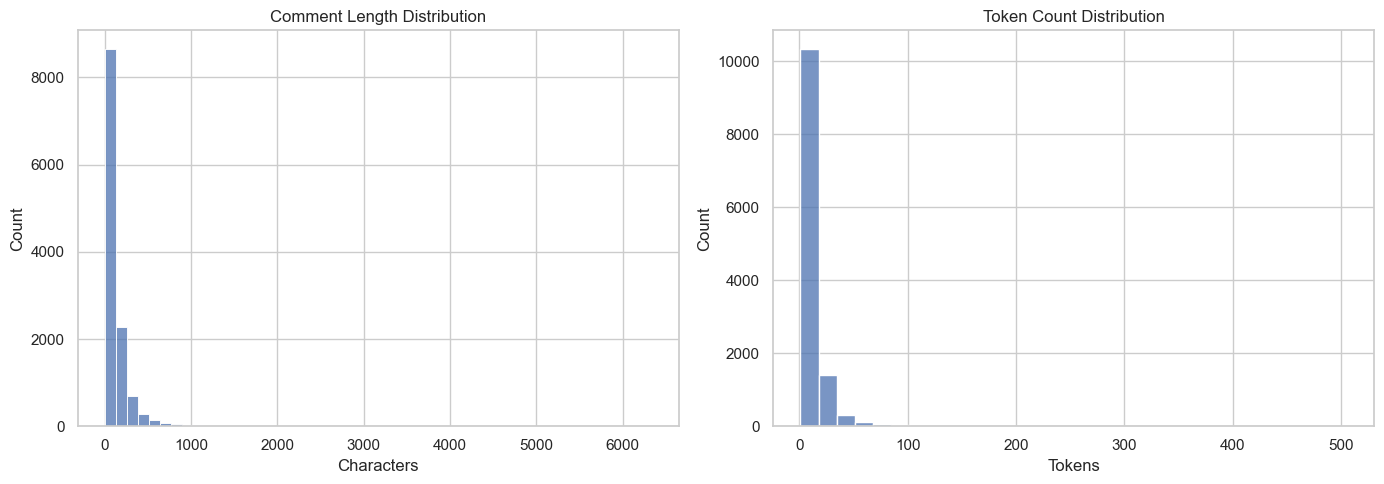

In [14]:
df["comment_length"] = df["text_clean_basic"].str.len()
df["token_count"] = df[TOKEN_COL].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["comment_length"], bins=50, ax=axes[0])
axes[0].set_title("Comment Length Distribution")
axes[0].set_xlabel("Characters")

sns.histplot(df["token_count"], bins=30, ax=axes[1])
axes[1].set_title("Token Count Distribution")
axes[1].set_xlabel("Tokens")

plt.tight_layout()
plt.show()

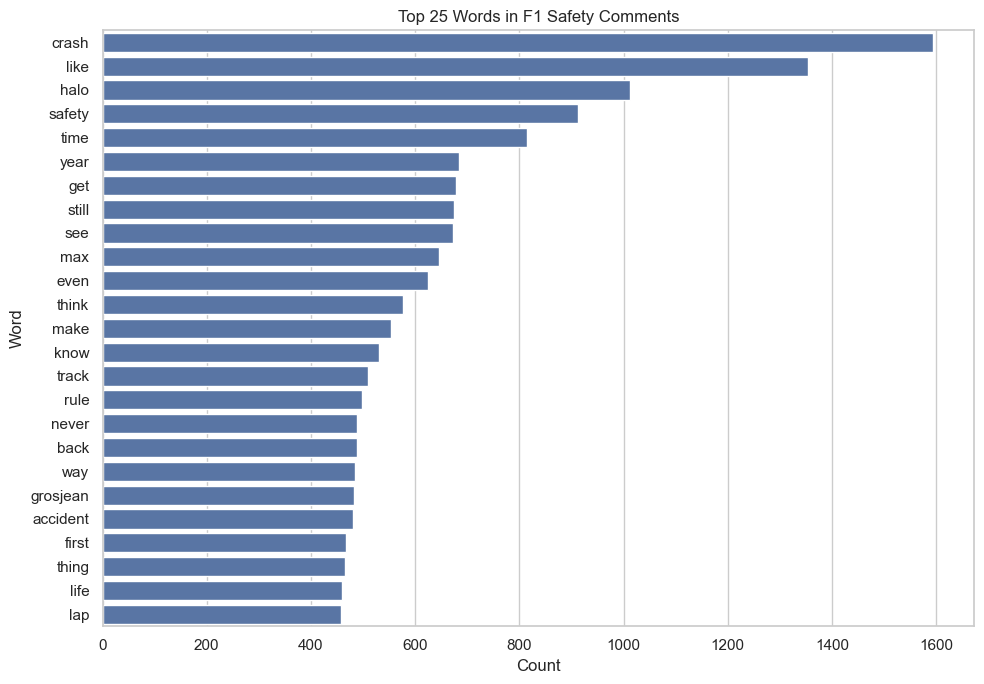

,word,count
0,crash,1593
1,like,1354
2,halo,1012
3,safety,912
4,time,814
5,year,684
6,get,678
7,still,674
8,see,672
9,max,646


In [15]:
# Top words after preprocessing
all_tokens = [tok for toks in df[TOKEN_COL] for tok in toks]
top_words = pd.DataFrame(Counter(all_tokens).most_common(25), columns=["word", "count"])

plt.figure(figsize=(10, 7))
sns.barplot(data=top_words, y="word", x="count")
plt.title("Top 25 Words in F1 Safety Comments")
plt.xlabel("Count")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

top_words.head(10)

## 11. TF-IDF and Bigram Analysis

This section applies TF-IDF and bigram analysis to identify the most important words and phrases appearing within YouTube discussions about Formula 1 safety.

These techniques help move beyond simple word frequency counts by highlighting terms that are both common and contextually meaningful within the dataset.

### TF-IDF Analysis

Term Frequency–Inverse Document Frequency (TF-IDF) is used to measure how important a word is within the comment corpus relative to the entire dataset.

Unlike raw frequency counts, TF-IDF reduces the influence of extremely common words and emphasises terms that are more distinctive or topic-specific. This makes it particularly useful for identifying important discussion themes and terminology related to Formula 1 safety.

The `TfidfVectorizer` is configured with:
- `max_features=1000` to limit vocabulary size
- `min_df=3` to remove extremely rare terms
- `max_df=0.85` to filter overly common terms that provide little analytical value

The resulting TF-IDF scores are averaged across all comments to identify the most influential and distinctive terms within the dataset.

Visualising the top TF-IDF terms helps reveal:
- Core safety-related concepts
- Frequently discussed incidents
- Technical terminology
- Emotional or opinion-driven language
- Regulatory and FIA-related discussions

This provides an initial understanding of the dominant themes emerging from the public discourse surrounding Formula 1 safety.

### Bigram Analysis

While TF-IDF focuses on individual words, bigram analysis examines pairs of consecutive words that frequently appear together.

This is important because many meaningful concepts in Formula 1 discussions are expressed as multi-word phrases rather than isolated terms. Examples may include:
- `"halo saved"`
- `"safety car"`
- `"fia rules"`
- `"driver safety"`
- `"red flag"`

The notebook uses `CountVectorizer` with:
- `ngram_range=(2,2)` to extract only bigrams
- `min_df=3` to remove infrequent phrases
- `max_features=500` to maintain manageable vocabulary size

The extracted bigrams are then ranked by frequency and visualised using bar charts.

Bigram analysis helps identify:
- Recurring discussion themes
- Common narratives within the community
- Safety-related terminology
- Public concerns and reactions
- Frequently referenced incidents or regulations

Together, TF-IDF and bigram analysis provide an interpretable overview of the language patterns within the dataset and help establish a foundation for later stages such as topic modelling, sentiment analysis, and semantic interpretation.

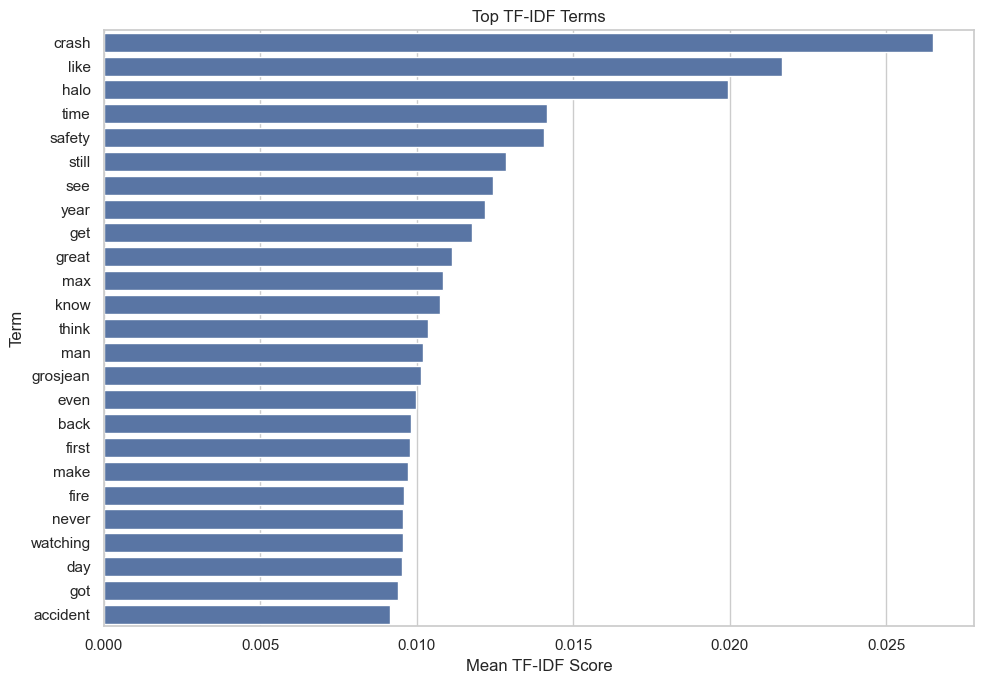

,term,score
178,crash,0.026486
514,like,0.021662
385,halo,0.019940
891,time,0.014162
752,safety,0.014080
838,still,0.012852
772,see,0.012444
991,year,0.012172
354,get,0.011761
371,great,0.011120


In [16]:
tfidf = TfidfVectorizer(max_features=1000, min_df=3, max_df=0.85)
X_tfidf = tfidf.fit_transform(df[TEXT_COL])

tfidf_scores = np.asarray(X_tfidf.mean(axis=0)).ravel()
tfidf_terms = tfidf.get_feature_names_out()

top_tfidf = pd.DataFrame({"term": tfidf_terms, "score": tfidf_scores})     .sort_values("score", ascending=False)     .head(25)

plt.figure(figsize=(10, 7))
sns.barplot(data=top_tfidf, y="term", x="score")
plt.title("Top TF-IDF Terms")
plt.xlabel("Mean TF-IDF Score")
plt.ylabel("Term")
plt.tight_layout()
plt.show()

top_tfidf.head(10)

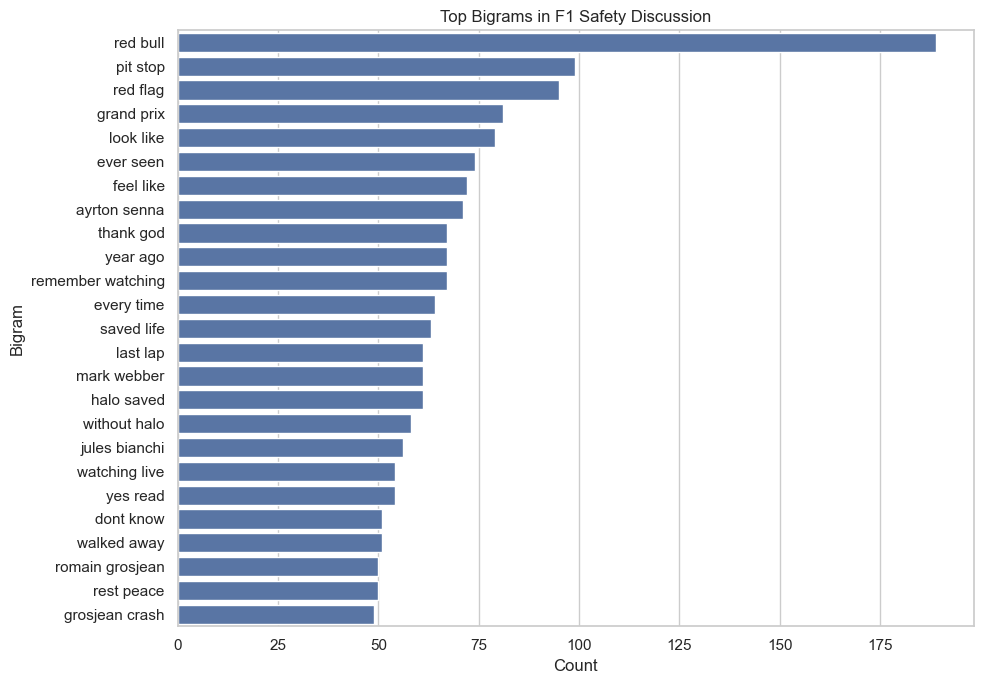

,bigram,count
346,red bull,189
335,pit stop,99
347,red flag,95
175,grand prix,81
256,look like,79
114,ever seen,74
127,feel like,72
19,ayrton senna,71
438,thank god,67
488,year ago,67


In [17]:
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2), min_df=3, max_features=500)
X_bigrams = bigram_vectorizer.fit_transform(df[TEXT_COL])

bigram_counts = np.asarray(X_bigrams.sum(axis=0)).ravel()
bigram_terms = bigram_vectorizer.get_feature_names_out()

top_bigrams = pd.DataFrame({"bigram": bigram_terms, "count": bigram_counts})     .sort_values("count", ascending=False)     .head(25)

plt.figure(figsize=(10, 7))
sns.barplot(data=top_bigrams, y="bigram", x="count")
plt.title("Top Bigrams in F1 Safety Discussion")
plt.xlabel("Count")
plt.ylabel("Bigram")
plt.tight_layout()
plt.show()

top_bigrams.head(10)

## 12. Sentiment Analysis: VADER and TextBlob

Sentiment analysis is used to examine the emotional tone and public opinion expressed within YouTube discussions about Formula 1 safety. Understanding sentiment is important because safety-related incidents often generate strong emotional reactions, including fear, anger, praise, criticism, and support for regulatory decisions.

This section applies two lexicon-based sentiment analysis techniques:
- **VADER (Valence Aware Dictionary and Sentiment Reasoner)**
- **TextBlob**

Using multiple sentiment methods allows the analysis to compare outputs and evaluate the consistency of sentiment classification across different approaches.

### VADER Sentiment Analysis

VADER is specifically designed for analysing social media and online conversational text. It performs well on informal language and can account for:
- Capitalisation
- Punctuation emphasis
- Slang and internet-style communication
- Emotional intensity

For each comment, VADER generates a compound sentiment score ranging from:
- `-1` (extremely negative)
- `+1` (extremely positive)

The notebook classifies comments into three categories using standard VADER thresholds:

- **Positive:** score ≥ 0.05  
- **Negative:** score ≤ -0.05  
- **Neutral:** otherwise  

VADER is particularly suitable for this project because YouTube comments often contain emotionally expressive language and informal writing patterns.

### TextBlob Sentiment Analysis

TextBlob is used as a secondary lexicon-based comparison model. It calculates sentiment polarity scores using a simpler rule-based approach.

Similar threshold values are applied to categorise comments into:
- Positive
- Neutral
- Negative

Although TextBlob is generally less specialised for social media text compared to VADER, it provides an additional reference point for evaluating sentiment consistency within the dataset.

### Sentiment Distribution Analysis

The resulting sentiment labels from both models are visualised using count plots to examine:
- Overall emotional trends
- Dominant public reactions
- Differences between sentiment methods

This helps identify whether Formula 1 safety discussions are primarily:
- Positive (supportive or appreciative)
- Negative (critical or emotional)
- Neutral (informational or balanced)

### Agreement Between Models

A heatmap is generated using a cross-tabulation between VADER and TextBlob sentiment labels.

This comparison helps evaluate:
- Areas of agreement between models
- Cases where sentiment interpretation differs
- The reliability and consistency of lexicon-based sentiment classification

High agreement between the two methods may indicate stable sentiment patterns, while disagreement may reveal:
- Ambiguous language
- Sarcasm
- Mixed emotional expression
- Context-dependent interpretations

Using multiple sentiment approaches strengthens the robustness of the analysis and provides deeper insight into how public opinion surrounding Formula 1 safety is expressed within online discussions.

In [18]:
sia = SentimentIntensityAnalyzer()

def vader_label(text):
    score = sia.polarity_scores(str(text))["compound"]
    if score >= 0.05:
        label = "positive"
    elif score <= -0.05:
        label = "negative"
    else:
        label = "neutral"
    return score, label


def textblob_label(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0.05:
        label = "positive"
    elif polarity < -0.05:
        label = "negative"
    else:
        label = "neutral"
    return polarity, label

vader_results = df["text_clean_basic"].apply(vader_label)
blob_results = df["text_clean_basic"].apply(textblob_label)

df["vader_score"] = vader_results.apply(lambda x: x[0])
df["vader_label"] = vader_results.apply(lambda x: x[1])
df["blob_score"] = blob_results.apply(lambda x: x[0])
df["blob_label"] = blob_results.apply(lambda x: x[1])

df[["text_clean_basic", "vader_score", "vader_label", "blob_score", "blob_label"]].head()

,text_clean_basic,vader_score,vader_label,blob_score,blob_label
0,"Gorsjean not only survived 160mph crash, but he stayed in the flames for 27seconds. That's just amazing how much saf...",0.8019,positive,0.225000,positive
1,Here’s kind of a sad fact: Romain Grosjean was actually very close to just staying down in the car because he was at...,-0.3811,negative,0.120635,positive
2,One of the scariest things about Grosjean’s crash is that the height of his body and the design of the barrier means...,-0.5719,negative,0.000000,neutral
3,that man who walked out of the fire said that the only reason he could walk out was because he thought about his chi...,-0.9061,negative,-0.400000,negative
4,"I was watching Bahrain 2020 live, I really thought I had just witnessed somebody die instantly. The fact that Grosje...",0.8957,positive,0.071591,positive


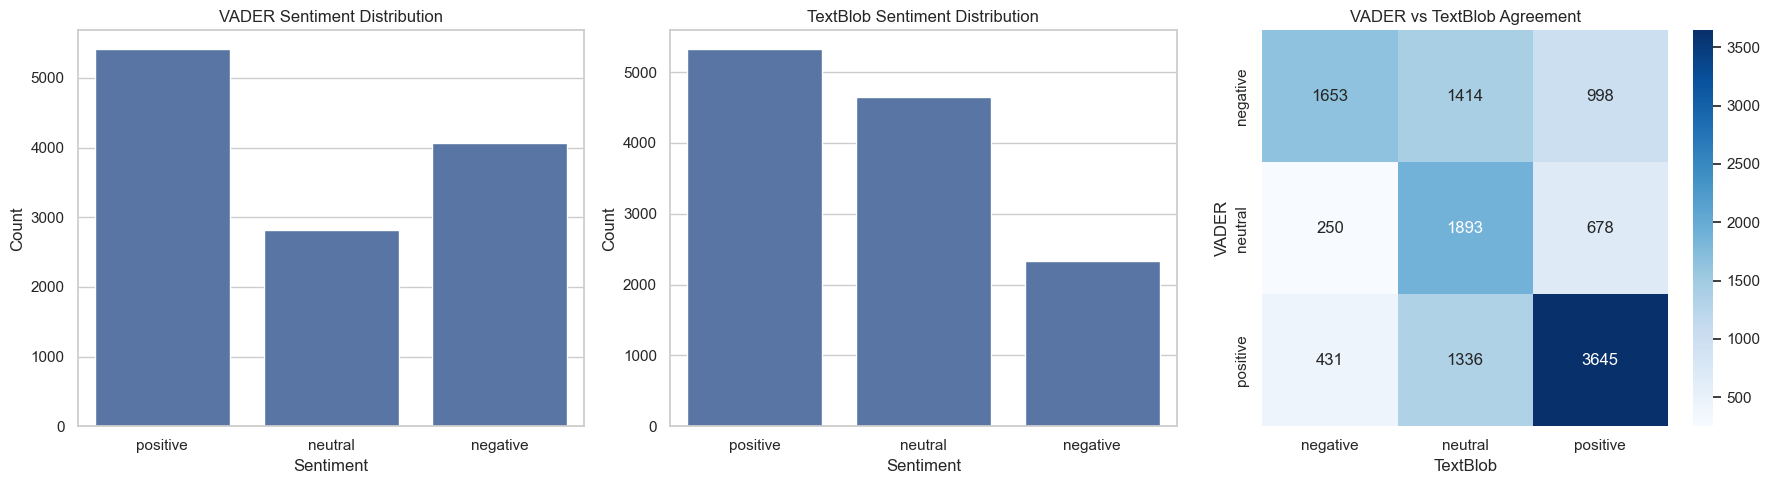

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x="vader_label", order=["positive", "neutral", "negative"], ax=axes[0])
axes[0].set_title("VADER Sentiment Distribution")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")

sns.countplot(data=df, x="blob_label", order=["positive", "neutral", "negative"], ax=axes[1])
axes[1].set_title("TextBlob Sentiment Distribution")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Count")

agreement = pd.crosstab(df["vader_label"], df["blob_label"])
sns.heatmap(agreement, annot=True, fmt="d", cmap="Blues", ax=axes[2])
axes[2].set_title("VADER vs TextBlob Agreement")
axes[2].set_xlabel("TextBlob")
axes[2].set_ylabel("VADER")

plt.tight_layout()
plt.show()

## 13. LDA

## 14. LSA

## 15. BERT / Sentence Embedding Analysis Optional Advanced Section

This section uses sentence embeddings to group semantically similar comments. It helps move beyond exact word matching and can strengthen the advanced analysis section.

If your machine is slow, sample the comments.

In [20]:
if HAS_SENTENCE_TRANSFORMERS:
    sample_size = min(1000, len(df))
    bert_sample = df.sample(sample_size, random_state=42).copy()

    model = SentenceTransformer("all-MiniLM-L6-v2")
    embeddings = model.encode(bert_sample["text_clean_basic"].tolist(), show_progress_bar=True)

    print("Embedding shape:", embeddings.shape)
else:
    print("sentence-transformers is not installed. Skip this section or install it first.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Embedding shape: (1000, 384)


In [21]:
# Optional: inspect semantic similarity between selected safety terms/comments
if HAS_SENTENCE_TRANSFORMERS:
    query_sentences = [
        "The halo saved the driver's life",
        "FIA safety rules are too strict",
        "Formula 1 is still very dangerous",
        "Modern safety technology has improved racing"
    ]
    query_embeddings = model.encode(query_sentences)
    sims = cosine_similarity(query_embeddings, embeddings)

    for i, q in enumerate(query_sentences):
        print("Query:", q)
        top_idx = sims[i].argsort()[-3:][::-1]
        for idx in top_idx:
            print("-", bert_sample.iloc[idx]["text_clean_basic"][:250])

Query: The halo saved the driver's life
- Funny to hear that driver thank Jules for saving his life when it was really the engineers who designed the halo and other safety features in the car. He didn’t have anything to do with the halo other than it was introduced as a safety measure after 
- Halo saved many lives.
- The Halo is an amazing addition to open racers. I've been watching F1 since the 70s and have seen so many lose their lives while racing. I say thank god for all who have survived crashes and to those we have lost, RIP. Its the safety changes that all
Query: FIA safety rules are too strict
- New title: Everything you need to know about safety in F1
- F1 trying to remind us what causes a safety car and why they improved safety
- Am I missing something? 15.3 surely doesn’t mean that the rules relating to the deployment or withdrawal of the safety car can be ignored and overridden by the whims of the race director. But only that if there was ever a disagreement between the ra

## 16. Network Construction: Word Co-occurrence Network

For A2, network analysis is essential. This section builds a word co-occurrence network where:

- nodes are important words
- edges connect words that appear in the same comment
- edge weight is the number of co-occurrences

This network shows which safety ideas are connected in public discussion.

In [22]:
def build_cooccurrence_network(token_lists, min_word_freq=20, window=None):
    word_counts = Counter(tok for toks in token_lists for tok in toks)
    vocab = {word for word, count in word_counts.items() if count >= min_word_freq}

    edge_counts = Counter()
    for toks in token_lists:
        toks = [t for t in toks if t in vocab]
        unique_tokens = list(dict.fromkeys(toks))

        if window is None:
            pairs_source = unique_tokens
            for i in range(len(pairs_source)):
                for j in range(i + 1, len(pairs_source)):
                    edge = tuple(sorted((pairs_source[i], pairs_source[j])))
                    edge_counts[edge] += 1
        else:
            for i in range(len(toks)):
                for j in range(i + 1, min(i + window, len(toks))):
                    if toks[i] != toks[j]:
                        edge = tuple(sorted((toks[i], toks[j])))
                        edge_counts[edge] += 1

    G = nx.Graph()
    for word, count in word_counts.items():
        if word in vocab:
            G.add_node(word, frequency=count)

    for (w1, w2), weight in edge_counts.items():
        if weight >= 3:
            G.add_edge(w1, w2, weight=weight)

    return G

G = build_cooccurrence_network(df[TOKEN_COL], min_word_freq=20)
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 1270
Edges: 93057


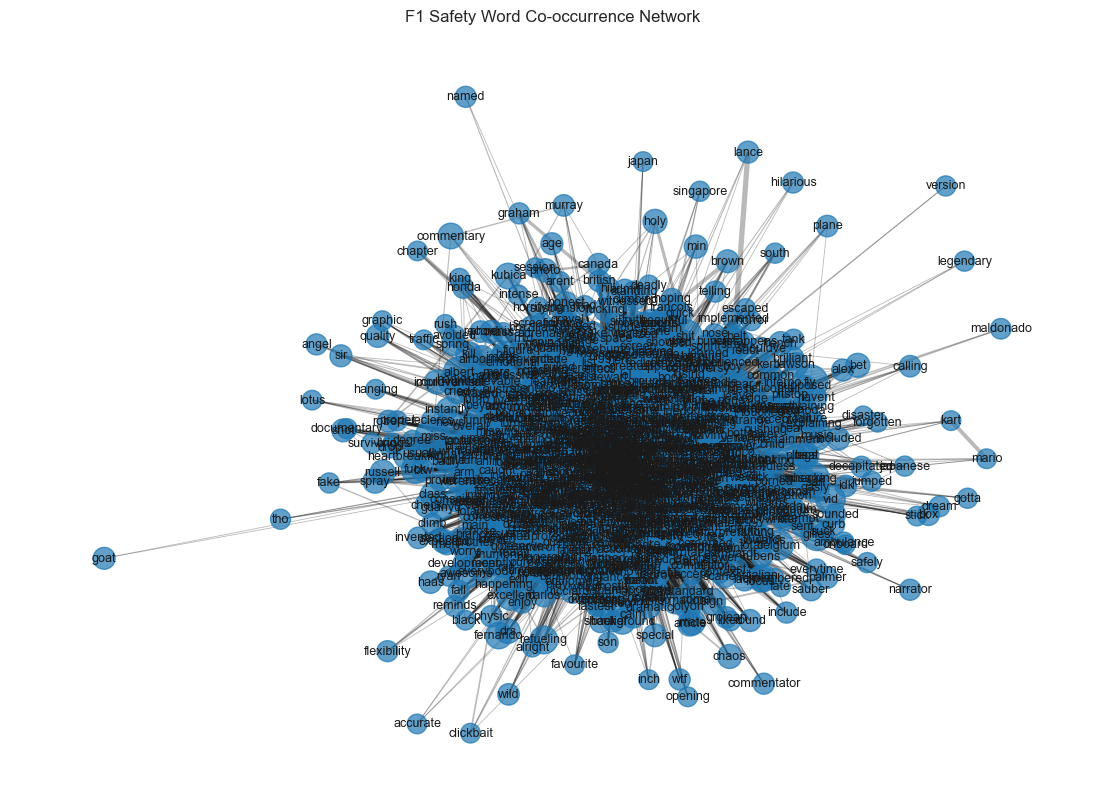

In [23]:
# Basic network visualisation
plt.figure(figsize=(14, 10))

# Use largest connected component for a cleaner visual
if G.number_of_nodes() > 0:
    largest_cc = max(nx.connected_components(G), key=len)
    G_vis = G.subgraph(largest_cc).copy()

    pos = nx.spring_layout(G_vis, k=0.5, seed=42)
    node_sizes = [G_vis.nodes[n]["frequency"] * 10 for n in G_vis.nodes]
    edge_widths = [G_vis[u][v]["weight"] * 0.2 for u, v in G_vis.edges]

    nx.draw_networkx_nodes(G_vis, pos, node_size=node_sizes, alpha=0.7)
    nx.draw_networkx_edges(G_vis, pos, width=edge_widths, alpha=0.3)
    nx.draw_networkx_labels(G_vis, pos, font_size=9)
    plt.title("F1 Safety Word Co-occurrence Network")
    plt.axis("off")
    plt.show()
else:
    print("Network is empty. Lower min_word_freq if needed.")